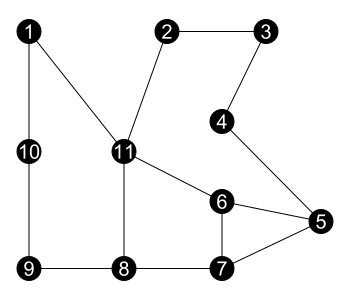

In [10]:
using Graphs  # Graphs package
using Karnak  # Graphs Visualization package

# Create graph
graph = Graphs.Graph(11)

# Edges
edges = [(1,10), (1,11), (2,3), (2,11), 
         (3,4), (4,5), (5,6), (5,7), 
         (6,7), (6,11), (7,8), (8,9), 
         (8,11), (9,10)]

# Add edges
for (u, v) in edges
    Graphs.add_edge!(graph, u, v)    
end

# Manually define the points for the layout
positions = [Point(0,0), Point(138,0), 
             Point(237,0), Point(193,90), 
             Point(292,190), Point(193,170), 
             Point(193,237), Point(95,237), 
             Point(0,237), Point(0,120), 
             Point(95,120)]

# Compute bounding box and center
xmin = minimum(p.x for p in positions)
xmax = maximum(p.x for p in positions)
ymin = minimum(p.y for p in positions)
ymax = maximum(p.y for p in positions)

# Calculate the center point of the bounding box
center_pt = Point((xmin + xmax)/2, (ymin + ymax)/2)

# Visualize the graph using Karnak
@drawsvg begin
    background("white")
    sethue("black")
    fontsize(20)
    # Translate so that the graph is centered
    translate(O - center_pt)
    drawgraph(
        graph,
        layout = positions,
        vertexshapesizes = 12,
        vertexlabels = 1:nv(graph)
    )
end 350 300

Vertex Cover set (C): [1, 3, 5, 7, 9, 11]


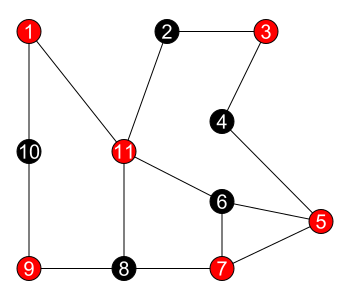

In [11]:
using JuMP, GLPK, Graphs, Karnak, Colors

# Create graph
g = Graph(11)

# Edges
edges = [(1,10), (1,11), (2,3), (2,11), 
         (3,4), (4,5), (5,6), (5,7), 
         (6,7), (6,11), (7,8), (8,9), 
         (8,11), (9,10)]

# Add edges
for (u, v) in edges
    Graphs.add_edge!(graph, u, v)    
end

# Total of vertices
n = nv(graph)

# Create the model
model = Model(GLPK.Optimizer)

# Define the decision variables
@variable(model, x[1:n], Bin)

# Objective function: minimize the total of selected vertices
@objective(model, Min, sum(x))

# Vertex Cover constraint
@constraint(model, [i = 1:n, j = 1:n; Graphs.has_edge(graph, i, j)], x[i] + x[j] >= 1)

# Run the solver
optimize!(model)

# Vertex Cover C
C = findall(JuMP.value.(x) .>= 0.5)

# Print solution
println("Vertex Cover set (C): $C")

# Manually define the points for the layout
positions = [Point(0,0), Point(138,0), 
             Point(237,0), Point(193,90), 
             Point(292,190), Point(193,170), 
             Point(193,237), Point(95,237), 
             Point(0,237), Point(0,120), 
             Point(95,120)]

# Compute bounding box and center
xmin = minimum(p.x for p in positions)
xmax = maximum(p.x for p in positions)
ymin = minimum(p.y for p in positions)
ymax = maximum(p.y for p in positions)

# Calculate the center point of the bounding box
center_pt = Point((xmin + xmax)/2, (ymin + ymax)/2)

# Visualize the graph using Karnak
@drawsvg begin
    background("white")
    sethue("black")
    fontsize(20)
    translate(O - center_pt) # Center the layout
    drawgraph(
        graph,
        layout = positions,
        vertexshapesizes = 12,
        vertexlabels = 1:Graphs.nv(graph),
        vertexfillcolors = (v) -> begin
            if v in C
                # Red for vertices in the cover
                Colors.RGB(1, 0, 0)
            end
        end
    )
end 350 300

Vertex Cover set (C): [1, 3, 5, 7, 9, 11]


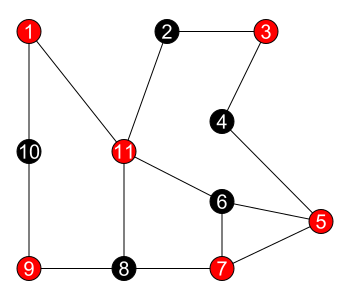

In [ ]:
# -------------------------------------------------------------
#  Code for: "Introduction to Integer Programming and Applications with Julia"
#  Chapter: 5 – Graph problems
#  Section: Exercise 2
#  Author(s): Luiz Henrique Nogueira Lorena
# -------------------------------------------------------------

using JuMP    # Modeling language
using HiGHS   # Solver
using Graphs  # Graphs package
using Karnak  # Graphs Visualization package
using Colors  # Colors package

# Function to plot the solution
function plot_solution(graph, positions, C)
    # Compute bounding box and center
    xmin = minimum(p.x for p in positions)
    xmax = maximum(p.x for p in positions)
    ymin = minimum(p.y for p in positions)
    ymax = maximum(p.y for p in positions)

    # Calculate the center point of the bounding box
    center_pt = Point((xmin + xmax)/2, (ymin + ymax)/2)

    # Draw graph
    n = Graphs.nv(graph)
    @drawsvg begin
        background("white")
        sethue("black")
        fontsize(20)
        translate(O - center_pt) # Center the layout
        drawgraph(
            graph,
            layout = positions,
            vertexshapesizes = 12,
            vertexlabels = 1:n,
            vertexfillcolors = [i in C ? Colors.RGB(1,0,0) : Colors.RGB(0,0,0) for i in 1:n]
        )
    end 350 300
end

# Function to solve the Vertex Covering Problem (VCP)
function solve_vcp(graph, positions)
    # Total of vertices
    n = Graphs.nv(graph)

    # Create the model
    model = JuMP.Model(HiGHS.Optimizer)

    # Silent mode (solver output is not printed)
    JuMP.set_silent(model)

    # Define the decision variables
    @variable(model, x[1:n], Bin)

    # Objective function: minimize the total of selected vertices
    @objective(model, Min, sum(x))

    # Vertex Cover constraint
    @constraint(model, [i = 1:n, j = 1:n; Graphs.has_edge(graph, i, j)], x[i] + x[j] >= 1)

    # Run the solver
    JuMP.optimize!(model)

    # Vertex Cover C
    C = findall(JuMP.value.(x) .>= 0.5)

    # Print solution
    println("Vertex Cover set (C): $C")

    # Plot solution
    plot_solution(graph, positions, C)
end

# Create graph
graph = Graphs.Graph(11)

# Edges
edges = [(1,10), (1,11), (2,3), (2,11), 
         (3,4), (4,5), (5,6), (5,7), 
         (6,7), (6,11), (7,8), (8,9), 
         (8,11), (9,10)]

# Add edges
for (u, v) in edges
    Graphs.add_edge!(graph, u, v)
end

# Manually define the vertices positions for the layout
positions = [Point(0,0), Point(138,0), 
             Point(237,0), Point(193,90), 
             Point(292,190), Point(193,170), 
             Point(193,237), Point(95,237), 
             Point(0,237), Point(0,120), 
             Point(95,120)]

# Solve the Vertex Covering Problem
solve_vcp(graph, positions)